In [ ]:
from pathlib import Path
import urllib.request

url = "https://homl.info/cars.mp4"
video_folder = (Path() / 'video').resolve()
video_folder.mkdir(parents=True, exist_ok=True)

cars_video = video_folder / 'cars.mp4'

urllib.request.urlretrieve(
	url, 
	cars_video
	)

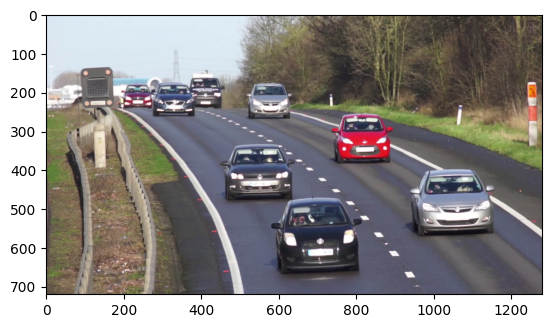

In [2]:
import cv2

cap = cv2.VideoCapture(cars_video)
ret, frame = cap.read()
frame.shape

import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [3]:
cap.get(cv2.CAP_PROP_FPS)

25.0

In [4]:
cap.get(cv2.CAP_PROP_FRAME_HEIGHT), cap.get(cv2.CAP_PROP_FRAME_WIDTH)

(720.0, 1280.0)

In [6]:
fps = cap.get(cv2.CAP_PROP_FPS)
int(1000/fps)

40

In [8]:
cap = cv2.VideoCapture(cars_video)
fps = cap.get(cv2.CAP_PROP_FPS)
counter = 0

while True:
	ret, frame = cap.read()

	if not ret:
		break

	if counter % 8 == 0:
		save_name = f'frame_{counter}.jpg'
		file_path = video_folder / save_name
		cv2.imwrite(file_path, frame)

	# cv2.imshow('videoooo', frame)

	# if cv2.waitKey(int(1000/fps)) & 0xFF == ord('x'):
	# 	break
	counter += 1

cap.release()
cv2.destroyAllWindows()

In [13]:
url = "https://homl.info/soccer.jpg"
image_folder = (Path() / 'images').resolve()
image_folder.mkdir(parents=True, exist_ok=True)

img_path = image_folder / 'soccer.jpg'
img_path

urllib.request.urlretrieve(
	url, 
	img_path
	)

(WindowsPath('C:/Users/user/Desktop/div/module4_dl/images/soccer.jpg'),
 <http.client.HTTPMessage at 0x263c5dbb3e0>)

In [25]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
import torch
from PIL import Image

weights = FCN_ResNet50_Weights.DEFAULT
model = fcn_resnet50(weights=weights)
model.eval()

transforms = weights.transforms()
transforms

SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [39]:
img = Image.open(img_path)
batch = transforms(img).unsqueeze(0)

with torch.no_grad():
	output = model(batch)['out'].softmax(dim=1)

In [56]:
cls_to_idx_map = {cl:id for id, cl in enumerate(weights.meta['categories'])}
person_idx = cls_to_idx_map['person']
mask = output[0, person_idx, ...]
mask.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0010, 0.0010, 0.0010],
        [0.0000, 0.0000, 0.0000,  ..., 0.0010, 0.0010, 0.0010],
        [0.0000, 0.0000, 0.0000,  ..., 0.0010, 0.0010, 0.0010],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.8620, 0.8620, 0.8620],
        [0.0000, 0.0000, 0.0000,  ..., 0.8620, 0.8620, 0.8620],
        [0.0000, 0.0000, 0.0000,  ..., 0.8620, 0.8620, 0.8620]])

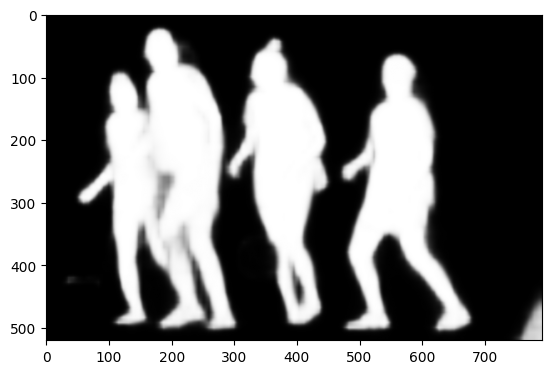

In [ ]:
plt.imshow(mask, cmap='gray')

In [61]:
mask.unsqueeze(0).shape

torch.Size([1, 520, 792])